# Autocorrelation and Auto-Regressive (AR) Model

An autoregressive model, written as AR(p), models a time series by regressing it on its own past observations (lags). The simplest specification is the AR(1) model, which includes only one lag of the series. A first-order autoregressive process for a time series $x_t$ can be written as:

$$
x_t = b_0 + b_1 x_{t-1} + \epsilon_t
$$

Here, $x_{t-1}$ is the value of the series at time $t-1$, and $\epsilon_t$ represents the error term at time $t$.

This framework can be generalized to an AR(p) model, which includes $p$ lagged terms:

$$
x_t = b_0 + b_1 x_{t-1} + b_2 x_{t-2} + \dots + b_p x_{t-p} + \epsilon_t
$$

For an AR model to produce meaningful and reliable estimates, the underlying time series must be **covariance stationary**. Covariance stationarity requires three key properties:

1. The expected value (mean) of the series remains constant and finite over time:
   $$
   E[y_t] = \mu, \quad \text{where } \mu < \infty \text{ for all } t.
   $$

2. The variance of the series is constant and finite across all time periods.

3. The covariance between the series and its lagged values depends only on the lag length (not on time itself), and remains finite and constant:
   $$
   \text{Cov}(y_t, y_{t-s}) = \lambda, \quad |\lambda| < \infty,
   $$
   where $\lambda$ is constant for  
   $$
   t = 1, 2, \dots, T \quad \text{and} \quad s = 0, \pm1, \pm2, \dots, \pm T.
   $$

Note that this covariance expression implicitly ensures that the variance (when $s = 0$) is constant, satisfying the second condition.

If these stationarity conditions are violated, the estimated parameters of the AR model may be biased, and statistical inference based on the model becomes unreliable. In practice, many financial time series—such as stock prices—exhibit trends and are therefore non-stationary. For instance, a stock price series may display a persistent upward drift, meaning its mean changes over time.

To properly apply an AR model, such non-stationary series must first be transformed into stationary ones (for example, through differencing). Once stationarity is achieved, the AR framework can be applied under the required assumptions.


**Import the necessary libraries**

In [60]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import statsmodels.tsa as tsa
from statsmodels.tsa.ar_model import AR, AutoReg
from statsmodels.stats.stattools import jarque_bera
from statsmodels.tsa.stattools import acf, pacf
from matplotlib import pyplot as plt

np.random.seed(0) # Ensures that the random numbers are the same each time the code is run

#### Simulated Data

Over here, we will be drawing sample data from a simulated $AR(3)$ model

In [27]:
def auto_regression_model(b, X, mu, sigma):
  """
  Simulate a single step of an autoregressive AR(p) process.

  The model follows the form: x_t = b0 + b1*x_{t-1} + ... + bp*x_{t-p} + ε_t

  Parameters
  ----------
  b : np.ndarray
      Array of coefficients of length (p + 1).
      b[0] is the intercept (b0).
      b[1:] are the lag coefficients (b1 ... bp).
  X : np.ndarray
      Array containing the most recent observations of the time series.
      The function uses the latest p values (if available).
  mu : float
      Mean of the Gaussian error term ε_t.
  sigma : float
      Standard deviation of the Gaussian error term ε_t.

  Returns
  -------
  float
      The next simulated value x_t of the AR(p) process.
  """

  # Determine the effective number of lags to use
  # (cannot exceed available observations or number of lag coefficients)
  l = min(len(b) - 1, len(X))

  # Extract intercept term
  b0 = b[0]

  # Compute the weighted sum of the most recent l observations
  # X[-l:] selects last l values
  # [::-1] reverses them to align with lag order (t-1, t-2, ...)
  ar_component = np.dot(b[1:l+1], X[-l:][::-1])

  # Draw Gaussian noise ε_t ~ N(mu, sigma^2)
  noise = np.random.normal(mu, sigma)

  # Return next AR value
  return b0 + ar_component + noise

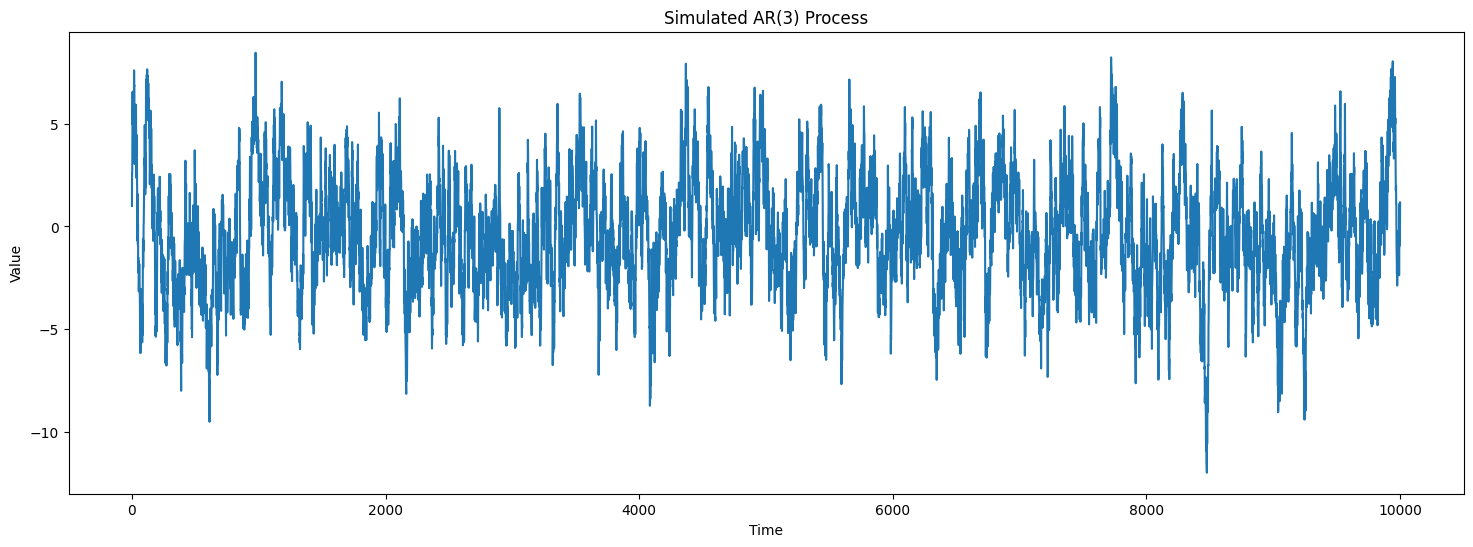

In [28]:
b = np.array([0, 0.8, 0.1, 0.05])
X = np.array([1])
mu = 0
sigma = 1

for _ in range(10000):
  X = np.append(X, auto_regression_model(b, X, mu, sigma))
  
plt.figure(figsize=(18, 6))
plt.plot(X)
plt.title('Simulated AR(3) Process')
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()

Remarks:

---

Notice how the process fluctuates around some central value. This value is the mean of our time series. Since we have a constant mean throughout time and the fluctuation seems to all stray within a given distance from the mean, we might hypothesise that this series is indeed **stationary**. We will want to be able to vigorously test this in practise, so we will explore this concept further in this notebook.

#### Tail Risk

Autoregressive (AR) processes tend to exhibit more extreme values compared to data drawn from a simple independent random process with a normal distribution. This occurs because each value in the series is influenced heavily by the most recent observations. If the series experiences a large random jump at some point, it is more likely to remain elevated (or depressed) for a while, rather than quickly reverting to the mean as would happen in a non-autoregressive series.

This property leads to what is known as "fat-tailed" behavior (increased kurtosis or leptokurtosis), where the probability density function shows more probability mass in the tails—meaning extreme events are more likely than they would be under a normal distribution.

Much of the discussion around tail risk in finance stems from the fact that autoregressive dynamics allow large tail events to actually occur and to cluster, making them difficult to model reliably due to their relative infrequency. While AR models are one common source of tail risk in time series, it is important not to automatically assume that any non-autoregressive series lacks tail risk—other mechanisms can also produce extreme behavior. We will now examine whether this specific series displays such characteristics.

In [29]:
def compare_tail_to_normal(X):
  """
  Compare empirical right-tail probabilities of a dataset to those implied by a fitted normal distribution.

  For thresholds of 1, 2, 3, and 4 (interpreted as standard deviation levels), this function computes:

  1. The empirical probability that X exceeds each threshold.
  2. The theoretical probability of exceeding the same threshold under a normal distribution fitted to X (same mean and std).

  Parameters
  ----------
  X : np.ndarray
    Array of observations.

  Returns
  -------
  np.ndarray
    A 2x4 matrix:
    - Row 0: empirical tail probabilities
    - Row 1: normal-distribution tail probabilities
  """
  A = np.zeros([2,4])
  for k in range(4):
    A[0, k] = len(X[X > (k + 1)]) / float(len(X))
    A[1, k] = 1 - stats.norm.cdf(k + 1, loc=np.mean(X), scale=np.std(X))
  print(f'Frequency of std events in X \n1: {A[0, 0]:.4f}, 2: {A[0, 1]:.4f}, 3: {A[0, 2]:.4f}, 4: {A[0, 3]:.4f}')
  print(f'Frequency of std events in normal distribution \n1: {A[1, 0]:.4f}, 2: {A[1, 1]:.4f}, 3: {A[1, 2]:.4f}, 4: {A[1, 3]:.4f}')
  return A

In [30]:
compare_tail_to_normal(X)

Frequency of std events in X 
1: 0.3056, 2: 0.2001, 3: 0.1153, 4: 0.0620
Frequency of std events in normal distribution 
1: 0.3108, 2: 0.1965, 3: 0.1122, 4: 0.0576


array([[0.30556944, 0.20007999, 0.11528847, 0.0619938 ],
       [0.31076509, 0.19645722, 0.11218208, 0.05755138]])

#### Estimation of Variance Will be Wrong

Estimates of variance for autoregressive (AR) processes are likely to be incorrect or misleading. This happens because AR processes often produce time series with heavy-tailed (non-normal) distributions of outcomes. In statistics, many standard tools and assumptions—especially those used to construct confidence intervals and calculate p-values—rely heavily on the normality of the data or of the sampling distribution of estimators.

When the underlying process has fat tails and non-normality, these conventional methods become unreliable. A particularly serious issue arises with p-values in hypothesis testing: their calculation frequently depends on an estimated variance (for example, in determining the width of confidence intervals for the mean). As a result, p-values derived from AR processes cannot be trusted in the usual way.

To illustrate this point, we will now examine it in practice. First, we will define some helper functions that compute a naive 95% confidence interval for the true mean of a given input time series. Later, we can apply these to see how the results behave under an AR process (as part of the Quotient Lecture Series or similar demonstration).


In [31]:
def compute_unadjusted_interval(X):
  T = len(X)
  mu = np.mean(X)
  sigma = np.std(X)
  lower = mu - 1.96 * sigma / np.sqrt(T)
  upper = mu + 1.96 * sigma / np.sqrt(T)
  return lower, upper

def check_unadjusted_coverage(X):
  lower, upper = compute_unadjusted_interval(X)
  if lower <= 0 and upper >= 0:
    return True
  return False

def simulate_AR_process(b, T):
  X = np.array([0])  # Start with an initial value
  mu = 0
  sigma = 1
  for _ in range(T):
    X = np.append(X, auto_regression_model(b, X, mu, sigma))
  return X

Let us now run an experiement 1000 times in which we will compute an AR series, and then estimate the mean and take the 95% CI around it. We will then check if the CI contains 0, the true long term mean of our series and record that in our outcomes array.

In [32]:
trials = 1000
outcomes = np.zeros((trials, 1))
b = np.array([0, 0.8, 0.1, 0.05])
confidence_intervals_range = []

for i in range(trials):
  X = simulate_AR_process(b, 1000)
  confidence_intervals_range.append(list(compute_unadjusted_interval(X)))
  if check_unadjusted_coverage(X):
    outcomes[i] = 1
  else:
    outcomes[i] = 0

Let us compute the percentage of our sample containing the true interval

In [33]:
print(f'Coverage of unadjusted confidence intervals: {np.mean(outcomes):.4f}')
print(f"Percentage of intervals that contain the true mean (0): {np.mean(outcomes) * 100:.2f}%")

Coverage of unadjusted confidence intervals: 0.2130
Percentage of intervals that contain the true mean (0): 21.30%


Let us plot and see the CIs from our simulations

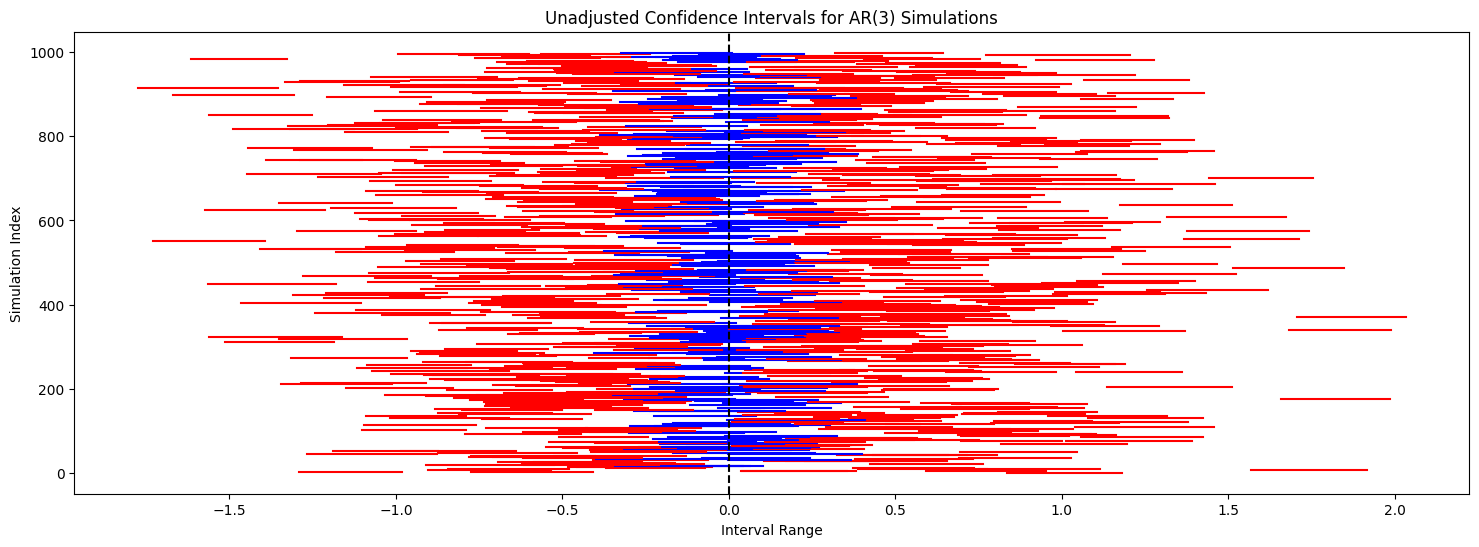

In [34]:
# Plot all the confidence intervals
plt.figure(figsize=(18, 6))
for i in range(trials):
  plt.plot(confidence_intervals_range[i], [i, i], color='blue' if outcomes[i] == 1 else 'red')
plt.axvline(x=0, color='black', linestyle='--')
plt.title('Unadjusted Confidence Intervals for AR(3) Simulations')
plt.xlabel('Interval Range')
plt.ylabel('Simulation Index')
plt.show()

Remarks:

---

It may look like something is incorrect, but the issue lies in the assumptions behind the variance estimate. The AR series fluctuates much more than expected, yet the variance calculation assumes the process is stationary and fails to account for this additional movement. As a result, the confidence intervals are far too narrow and do not capture the true value as often as they should.

This creates a misleading sense of precision and reliability. Proper stationarity tests should detect the autoregressive structure and warn us that the variance estimates—and consequently the confidence intervals—are likely to be inaccurate.

**Correcting for Variance**

In practise, it can be very difficult to accurately estimate variance on an AR series, but one attempt to do this is to use the *Newey-West Estimation*.

#### Testing for AR Behavior

In order to determine the order *p* of an AR(*p*) model, we look at the **autocorrelations** of the time series. These are the correlations of the series with its own past values.

The lag-*k* autocorrelation is defined as:

$$
\rho_k = \frac{\text{COV}(x_t, x_{t-k})}{\sigma^2} = \frac{E[(x_t - \mu)(x_{t-k} - \mu)]}{\sigma^2}
$$

where *k* represents the number of periods lagged.

We cannot directly observe the true autocorrelations, so we estimate them using the sample autocorrelations:

$$
\hat{\rho}_k = \frac{\sum_{t=k+1}^T (x_t - \bar{x})(x_{t-k} - \bar{x})}{\sum_{t=1}^T (x_t - \bar{x})^2}
$$

For our purposes, we can use two key tools to help determine the order of the model:

- the **Autocorrelation Function (ACF)**  
- the **Partial Autocorrelation Function (PACF)**

The PACF adjusts for (controls out) the influence of shorter lags when looking at longer lags in the ACF. These functions are included in most modern statistical and time-series packages (e.g. `statsmodels`, `pandas`, `R`, etc.).

We will now demonstrate these functions using the example of a stationary series shown above, compute the sample autocorrelations, and use them to identify an appropriate value of *p*.

In [35]:
b = np.array([0, 0.8, 0.1, 0.05])
timesteps = 1000
X = simulate_AR_process(b, timesteps)

# For here, we will be choosing 40 lags. This is a little arbitrary, but it is a common choice for visualizing autocorrelation in time series data. The number of lags can be adjusted based on the specific characteristics of the data and the context of the analysis.
lags = 40
x_acf = acf(X, nlags=lags)
print(f'ACF values for lags 0 to {lags}: \n{x_acf}')
x_pacf = pacf(X, nlags=lags)
print(f'PACF values for lags 0 to {lags}: \n{x_pacf}')

ACF values for lags 0 to 40: 
[1.         0.92251976 0.87324522 0.83886784 0.79789961 0.75869073
 0.72018435 0.68705949 0.65319375 0.62238196 0.59381635 0.56552676
 0.53928127 0.51479407 0.4887923  0.4689388  0.44574878 0.42542533
 0.40342131 0.38606216 0.3690715  0.34672689 0.33020006 0.30858727
 0.28639568 0.26648681 0.24615116 0.22725485 0.20448894 0.18502285
 0.16412533 0.14258099 0.13264632 0.11056182 0.10345756 0.0930353
 0.07183557 0.05006201 0.03630912 0.02101184 0.00413339]
PACF values for lags 0 to 40: 
[ 1.00000000e+00  9.23442283e-01  1.51084226e-01  1.10797045e-01
 -2.05035143e-02 -5.89896614e-03 -1.80507229e-02  2.00137067e-02
 -9.82609442e-03  1.05539461e-02  5.18641430e-03 -2.58427604e-03
  2.88327379e-03  4.56518911e-03 -1.68740004e-02  2.90973056e-02
 -2.14755728e-02  1.02050901e-02 -2.16767579e-02  2.22569881e-02
  3.80509976e-05 -3.58106194e-02  1.36567593e-02 -3.98701164e-02
 -2.24180551e-02 -8.19503282e-03 -1.24885861e-02 -3.16718149e-03
 -3.79934243e-02 -2.024046

Plottiing the ACF and PACF

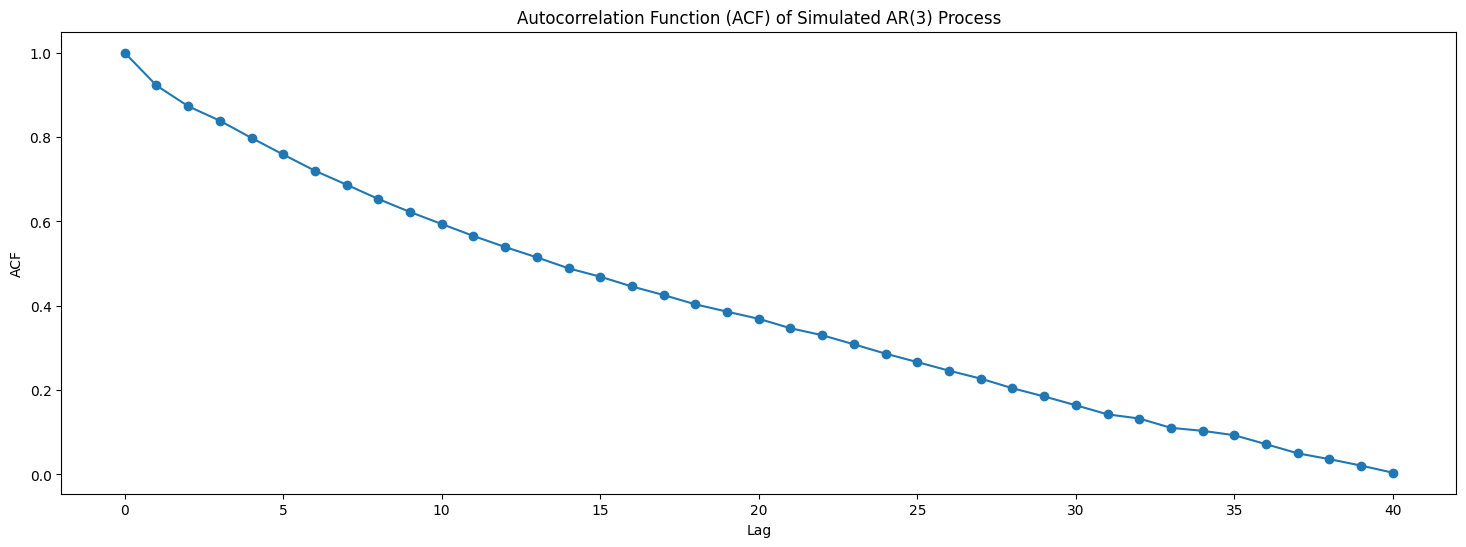

In [36]:
plt.figure(figsize=(18, 6))
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.plot(range(len(x_acf)), x_acf, marker='o')
plt.title('Autocorrelation Function (ACF) of Simulated AR(3) Process')
plt.show()

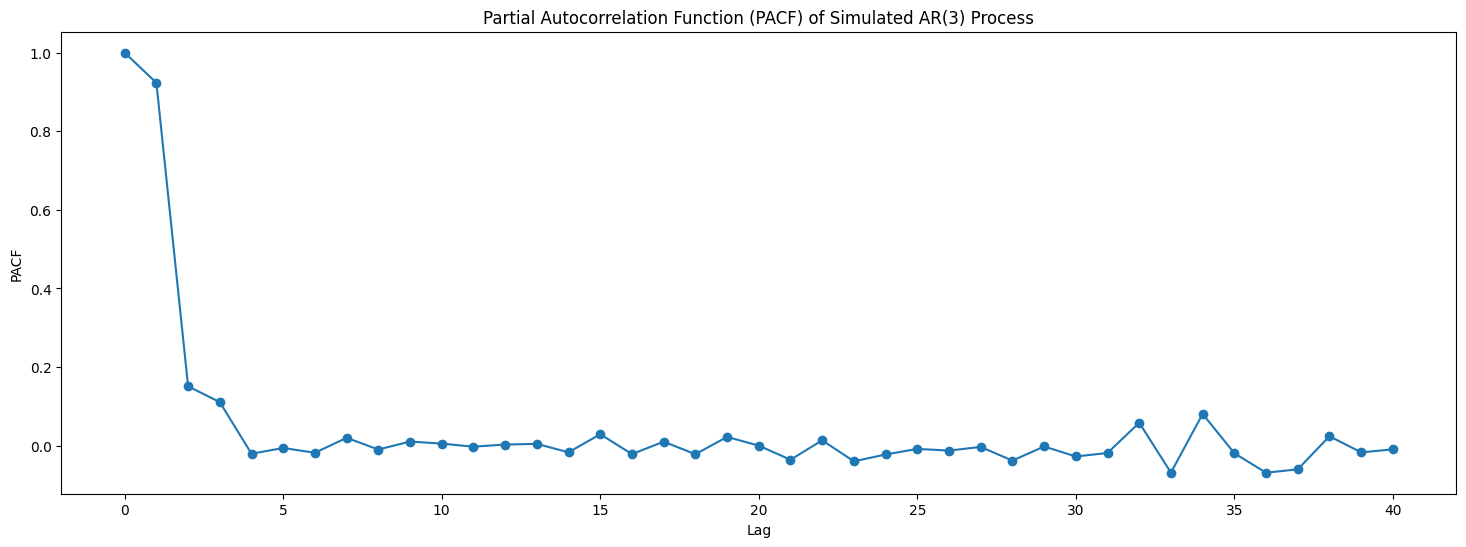

In [37]:
plt.figure(figsize=(18, 6))
plt.xlabel('Lag')
plt.ylabel('PACF')
plt.plot(range(len(x_pacf)), x_pacf, marker='o')
plt.title('Partial Autocorrelation Function (PACF) of Simulated AR(3) Process')
plt.show()

**Statistical Testing**

Just looking at the graphs alone is not enough. We need to apply a degree of statistical rigor when interpreting the results. The `acf()` and `pacf()` functions (in most statistical packages) will typically return **confidence intervals** around all the estimated autocorrelations. To determine statistical significance:

- Check whether these confidence intervals overlap with zero.
- If a given lag's confidence interval **does not include zero**, we can say that the autocorrelation at that lag is statistically different from zero (i.e., the lag is "significant").
- If the interval **does include zero**, we generally do not reject the null hypothesis that the true autocorrelation at that lag is zero.

**Important note:**  
This rule of thumb only works reliably if the assumptions underlying the confidence interval calculations are satisfied. Always verify these assumptions before interpreting the results as meaningful.

The specific assumptions can vary depending on the method used to compute the intervals (e.g., Bartlett's formula for ACF under white noise, different approximations for PACF, etc.). Please consult the documentation for the specific function or package you are using (e.g. `statsmodels`, `R`'s `acf`/`pacf`, etc.) and check the assumptions for your own test before drawing strong conclusions.

In [38]:
x_acf, x_acf_confs = acf(X, nlags=lags, alpha=0.05)
x_pacf, x_pacf_confs = pacf(X, nlags=lags, alpha=0.05)

In [43]:
def plot_acf_with_confidence_intervals(x_acf, x_acf_conf, title="ACF"):
  errorbars = np.ndarray((2, len(x_acf)))
  errorbars[0, :] = x_acf - x_acf_conf[:, 0]  # Distance from ACF to lower confidence bound
  errorbars[1, :] = x_acf_conf[:, 1] - x_acf  # Distance from ACF to upper confidence bound
  plt.figure(figsize=(18, 6))
  plt.plot(range(len(x_acf)), x_acf, marker='o')
  plt.errorbar(range(len(x_acf)), x_acf, yerr=errorbars, fmt='none', ecolor='gray', alpha=0.5, label='95% Confidence Interval')
  plt.axhline(0, color='black', linestyle='--')
  plt.title(f'{title} of Simulated AR(3) Process with Confidence Intervals')
  plt.xlabel('Lag')
  plt.ylabel(title)
  plt.legend()
  plt.show()

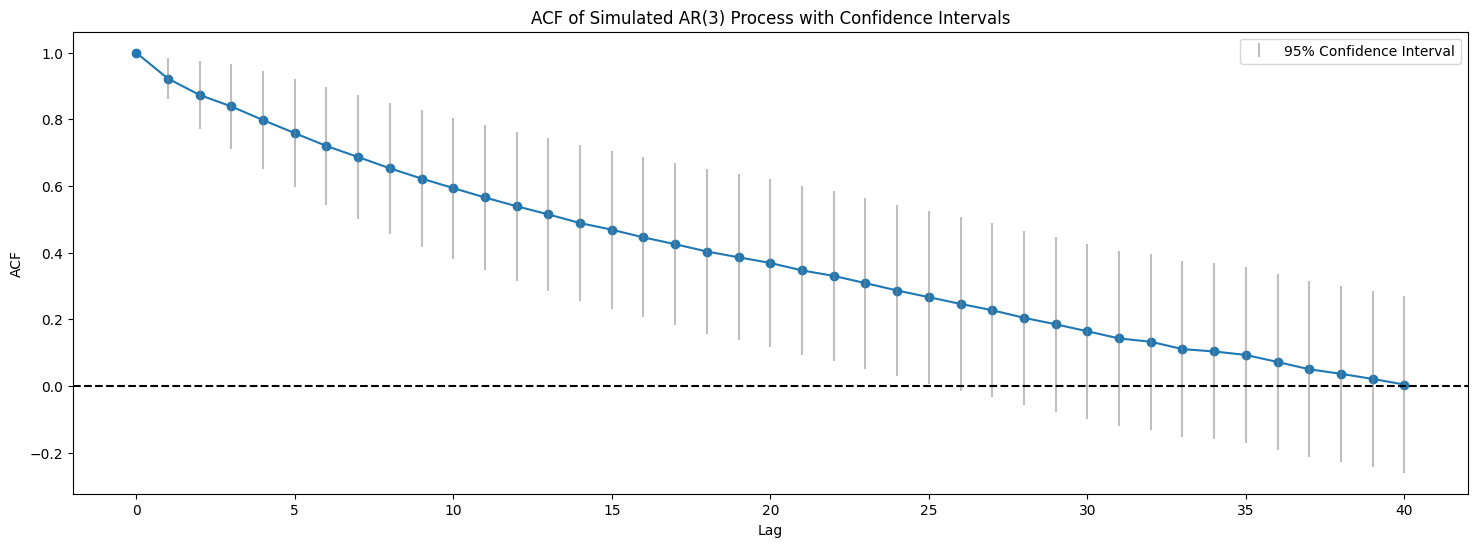

In [44]:
plot_acf_with_confidence_intervals(x_acf, x_acf_confs, title="ACF")

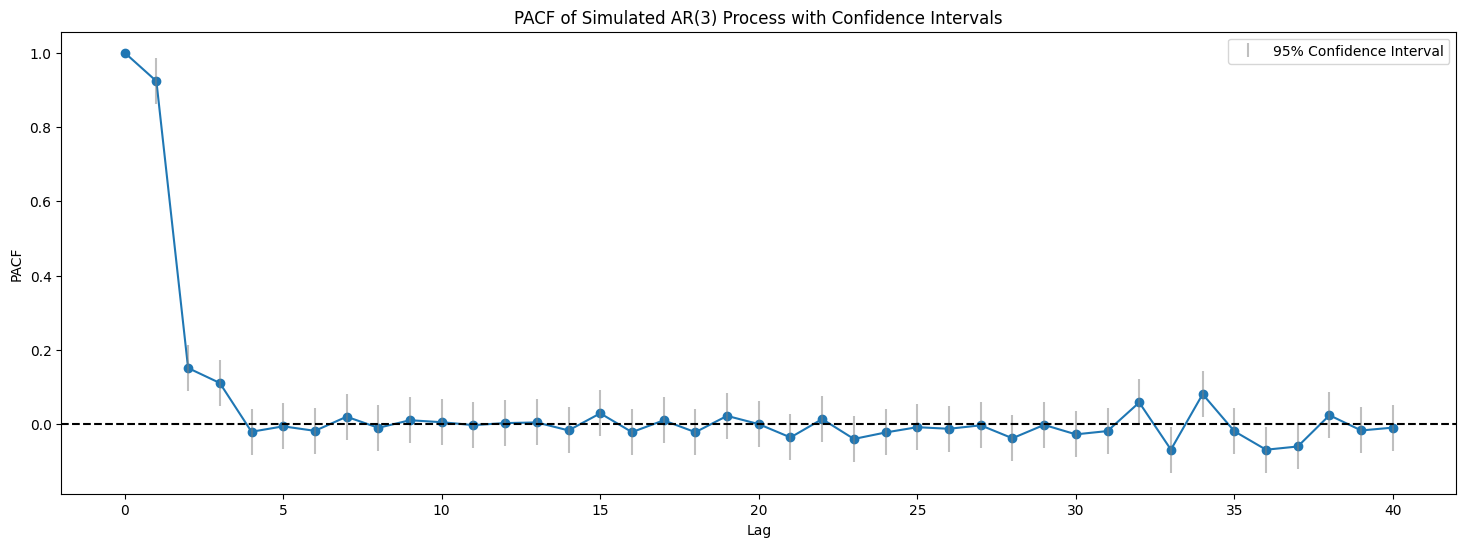

In [45]:
plot_acf_with_confidence_intervals(x_pacf, x_pacf_confs, title="PACF")

Notice how for the PACF, the first 3 lags are the only ones that appear to be significantly different from 0, which makes sense because we directly constructed an AR model of order 3. However, these results may differ for each random seed series we generate in this notebook.

In the real world time series, we will use these plots to determine the order of our model. We would then attempt to fit a model using the maximum likelihood function.

#### Fitting a Model

In [51]:
# Construct an unfitted model
model = tsa.api.AutoReg(X, lags=20)
model = model.fit()

Let us view some information on the fitted model

In [52]:
print("Parameters of the fitted AR(3) model:")
print(model.params)
print("Standard Errors of the parameters:")
print(model.bse)

Parameters of the fitted AR(3) model:
[ 3.57104047e-02  7.62617142e-01  6.55379302e-02  1.36570085e-01
 -1.43111665e-02  1.22879092e-02 -3.67237481e-02  2.06441559e-02
 -2.25409029e-02  5.64739449e-03  8.79811847e-03 -2.07921199e-03
 -3.17843005e-04  2.18490107e-02 -3.79315712e-02  4.70069410e-02
 -2.98371294e-02  2.45446748e-02 -4.12519348e-02  2.03985758e-02
  8.75984302e-04]
Standard Errors of the parameters:
[0.03340656 0.03192555 0.04014454 0.04017514 0.0404127  0.04042849
 0.0404285  0.04043609 0.04042495 0.04043351 0.04045411 0.04063354
 0.04062456 0.04060225 0.04052762 0.04053453 0.04054041 0.04053746
 0.04039542 0.04036347 0.03197123]


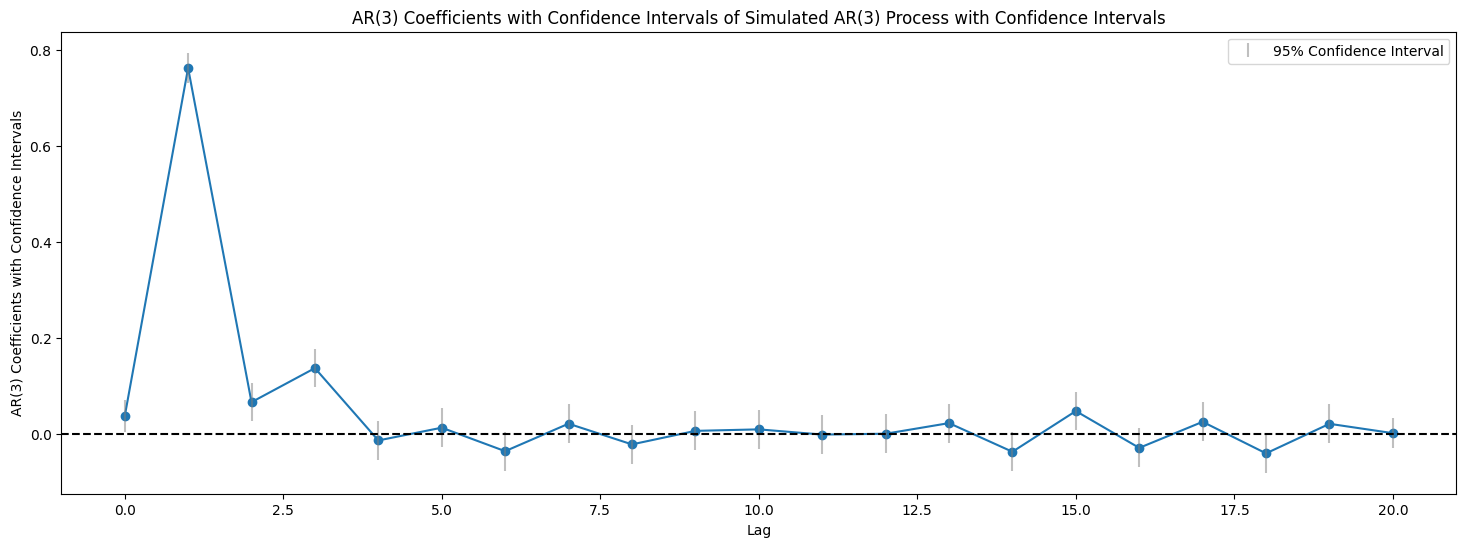

In [53]:
model_coeffs = np.asarray((model.params - model.bse, model.params + model.bse)).T
plot_acf_with_confidence_intervals(model.params, model_coeffs, title="AR(3) Coefficients with Confidence Intervals")

#### Choosing the Number of Lags

**Estimations Will Include Too Many Lags**

If we allow the model to include too many parameters (lags), we know there will be too many because we simulated the data as an AR(1) or AR(3) process.   AR models will often estimate many more lags than actually exist due to **indirect dependency**.  

If $X_t$ depends directly on $X_{t-1}$, it will also indirectly (and to a lesser extent) depend on $X_{t-2}$, $X_{t-3}$, etc. In the presence of more than one lag in the true generating process, these indirect dependencies will be picked up in the estimation, leading to potentially complex harmonic-like structures in the estimated lags.

**You Want the Fewest Parameters That Yield a Decent Model**

In general, the goal is to find a model with the fewest parameters that still provides a good, useful fit (see the Overfitting lecture in the Quantopian Lecture Series for why more parameters can be harmful). Here, we want to select a number of lags that we believe explains what is happening, without overfitting by including way too many lags.

Observing the ACF and PACF, we see that only the first 1–3 lags appear meaningful. However, to be thorough, we will expand the search and fit models with up to 10 lags, then use information criteria — specifically the **Akaike Information Criterion (AIC)** and **Bayesian Information Criterion (BIC)** — to help decide on the appropriate number of lags. For more information on model selection using information criteria, please refer to the corresponding lecture in the Quantopian Lecture Series.

**Interpreting AIC and BIC**

Compute the AIC and BIC for all models under consideration. Identify the smallest values:

- $AIC_{min}$ — the model that minimizes the Akaike Information Criterion  
- $BIC_{min}$ — the model that minimizes the Bayesian Information Criterion  

These are the models that minimize information loss according to each criterion. For any model $i$, we can compute the **relative likelihood** compared to the best model using:

$$
L_i = e^{(AIC_{min} - AIC_i)/2}
$$

(or similarly for BIC).  

This value can be interpreted as: Model $i$ is $L_i$ times as likely as the minimum-AIC model to minimize information loss.  

It may take a few examples to see this in action and build intuition.

In [58]:
N = 10
AIC = np.zeros((N, 1))
for i in range(N):
  model = tsa.api.AutoReg(X, lags=i)
  model = model.fit()
  AIC[i] = model.aic
  
AIC_min = np.min(AIC)
model_min = np.argmin(AIC)

print("Relative Likelihoods")
print(np.exp((AIC_min - AIC) / 2))
print("Number of parameters in min AIC model:", model_min+1)


Relative Likelihoods
[[0.00000000e+00]
 [1.49497490e-10]
 [1.47830568e-05]
 [7.06514854e-03]
 [8.61801431e-03]
 [2.67361528e-02]
 [3.19376182e-02]
 [4.43290578e-02]
 [5.49247297e-01]
 [1.00000000e+00]]
Number of parameters in min AIC model: 10


In [59]:
N = 10
BIC = np.zeros((N, 1))
for i in range(N):
  model = tsa.api.AutoReg(X, lags=i)
  model = model.fit()
  BIC[i] = model.bic
  
BIC_min = np.min(BIC)
model_min = np.argmin(BIC)

print("Relative Likelihoods")
print(np.exp((BIC_min - BIC) / 2))
print("Number of parameters in min BIC model:", model_min+1)

Relative Likelihoods
[[0.00000000e+00]
 [2.84937752e-06]
 [2.42685509e-02]
 [1.00000000e+00]
 [1.05274036e-01]
 [2.82153376e-02]
 [2.91473250e-03]
 [3.50213397e-04]
 [3.76009789e-04]
 [5.93824006e-05]]
Number of parameters in min BIC model: 4


Our conclusion here is that the AIC estimates the 10 parameter model as the most likely, but the BIC estimates 4. As we are always looking for reasons to knock off parameters, we will be choosing 4 in this case.

#### Evaluating Residuals

As a final step before performing an out-of-sample test on this model, we should evaluate the behavior of the **residuals**.

The AIC and BIC criteria already provide some indirect assessment of this: they effectively measure how much unexplained information (i.e., “information left on the table”) remains in the residuals after the model has made its predictions.

Specifically, we will focus on checking the **normality** of the residuals.

In [61]:
model = tsa.api.AutoReg(X, lags=model_min)
model = model.fit()

score, pvalue, _, _ = jarque_bera(model.resid)
if pvalue < 0.05:
  print("Residuals are not normally distributed (reject null hypothesis)")
else:
  print("Residuals are normally distributed (fail to reject null hypothesis)")

Residuals are normally distributed (fail to reject null hypothesis)
